# Energy Scale Calibration - NEXT-100 HE data

Energy scale calibration of the NEXT-100 detector using known peaks from the Th-228 source.

## Purpose
Determine the linear relationship between measured and true energy by fitting 5 calibration
peaks: 511 keV (e+e-), 583 keV (Tl-208), 727 keV (Bi-212), 1592 keV (DEP), 2615 keV (PP).

## Workflow
1. **Data loading**: Read DST, RECO and efficiencies from 8 runs (15589-15597)
2. **Energy correction**: Subtract energy lost at detector edges (`Ec_drop_out`)
3. **Global spectrum**: Full energy histogram (0.1 - 3.5 MeV)
4. **Peak fitting**: Gaussian + exponential model for each peak range
5. **Energy scale**: Measured vs true comparison, FWHM/E calculation, extrapolation to Qbb

## Key result
Energy resolution (FWHM/E) as a function of energy, extrapolated to Q_betabeta ~ 2458 keV.

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
import hipy.utils        as ut
import hipy.histos       as histos
import hipy.pltext       as pltext
import hipy.profile      as prof

#import nana.kr.krana    as krana
#import nana.kr.kr100ana as krn100
#import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
pltext.style()

## Data loading
Load 8 HE calibration runs. For each run, three HDF5 tables are read:
- `DST/Events`: DST data
- `RECO/Events_summary`: reconstruction summary (energy, position, nhits)
- `RUN/eff`: selection efficiencies

In [ ]:
pathdata = "/Users/hernando/work/investigacion/NEXT/data/NEXT100/data/hesum/"
run_numbers = [15589, 15590, 15591, 15592, 15593, 15594, 15596, 15597]


In [27]:
dst_summ, reco_summ, eff_summ = pd.DataFrame([]), pd.DataFrame([]), pd.DataFrame([])
for run_n in run_numbers:
    filename = pathdata + f"run_cut_{run_n}.h5"
    #path= path.format(run_folder = run_folder, run_number = run_n) + run_summary_name.format(run_n)
    run_dst  = pd.read_hdf(filename, 'DST/Events')
    run_dst['run_n'] = str(run_n)
    run_reco = pd.read_hdf(filename, 'RECO/Events_summary')
    eff = pd.read_hdf(filename, 'RUN/eff')
    eff['run_n'] = run_n

    dst_summ = dst_summ.append(run_dst)
    reco_summ = reco_summ.append(run_reco)
    eff_summ = eff_summ.append(eff)

In [37]:
reco_summ = reco_summ.fillna({'Ec_drop_in': 0, 'Ec_drop_out':0})
reco_summ['total_energy_d'] = reco_summ['total_energy'] - reco_summ['Ec_drop_out'] # - reco_summ['Ec_drop_in']

## Energy spectrum and correction
Correct total energy by subtracting the edge-hit contribution (`Ec_drop_out`).
`total_energy_d = total_energy - Ec_drop_out`

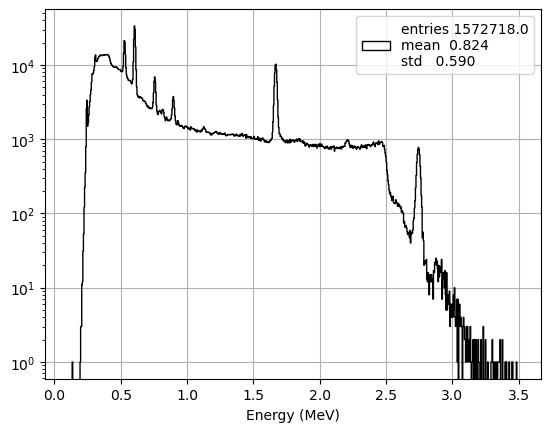

In [49]:
pltext.hist(reco_summ.total_energy_d, 800, (.1, 3.5));
plt.xlabel('Energy (MeV)'); plt.yscale('log');

In [ ]:
def get_peak(energy, bins = 100, range = (0, 3e3))
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    


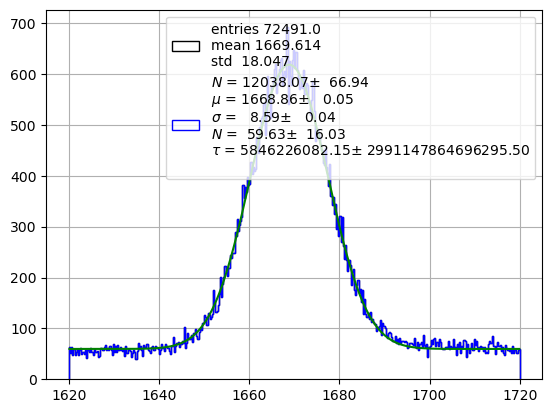

In [64]:
scale = 1e3
pltext.hist(scale*reco_summ.total_energy_d, 400, (scale*1.62, scale*1.72));
pltext.hfit(scale*reco_summ.total_energy_d, 400, fun = 'gaus+exp', range = (scale*1.62, scale*1.72));

In [209]:
reco_summ

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out,total_energy_d
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21,1.843904
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16,0.346503
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10,1.788487
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16,0.372155
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14,0.747150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12,0.596266
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9,0.360555
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4,0.614114
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20,0.355775


In [219]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n) ].total_energy_d
print(len(energy))
#pltext.hist(1e3*energy, 500, (0, 3.8e6));

206103


## Calibration peak fitting
For each known Th-228 peak, fit a Gaussian + exponential model
to extract the peak position (mu) and width (sigma).

Peaks fitted: 511, 583, 727, 1592, 2615 keV

In [220]:
run_n = run_numbers[0]
energy = reco_summ[reco_summ.run_n == str(run_n)].total_energy_d.values
bins   = 400
range = (1620, 1720)
def get_peak(energy, range, bins = 100):
    _, _, _, pars, epars, _ = histos.hfit(energy, bins, fun = "gaus+exp", range = range)
    mu, sigma = pars[1], pars[2]
    emu, esigma = epars[1], epars[2]
    return mu, emu, sigma, esigma

In [221]:
peak_ranges   = [(0.5, 0.58), (0.58, 0.65), (0.72, 0.81), (0.85, 0.95), (1.62, 1.75), (2.7, 2.8)]
peak_ranges_d = [(0.48, 0.56), (0.57, 0.64), (0.71, 0.80), (0.85, 0.95), (1.59, 1.72), (2.68, 2.79)]

/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/Users/hernando/miniconda/envs/IC-3.8-2022-04-13/lib/python3.8/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


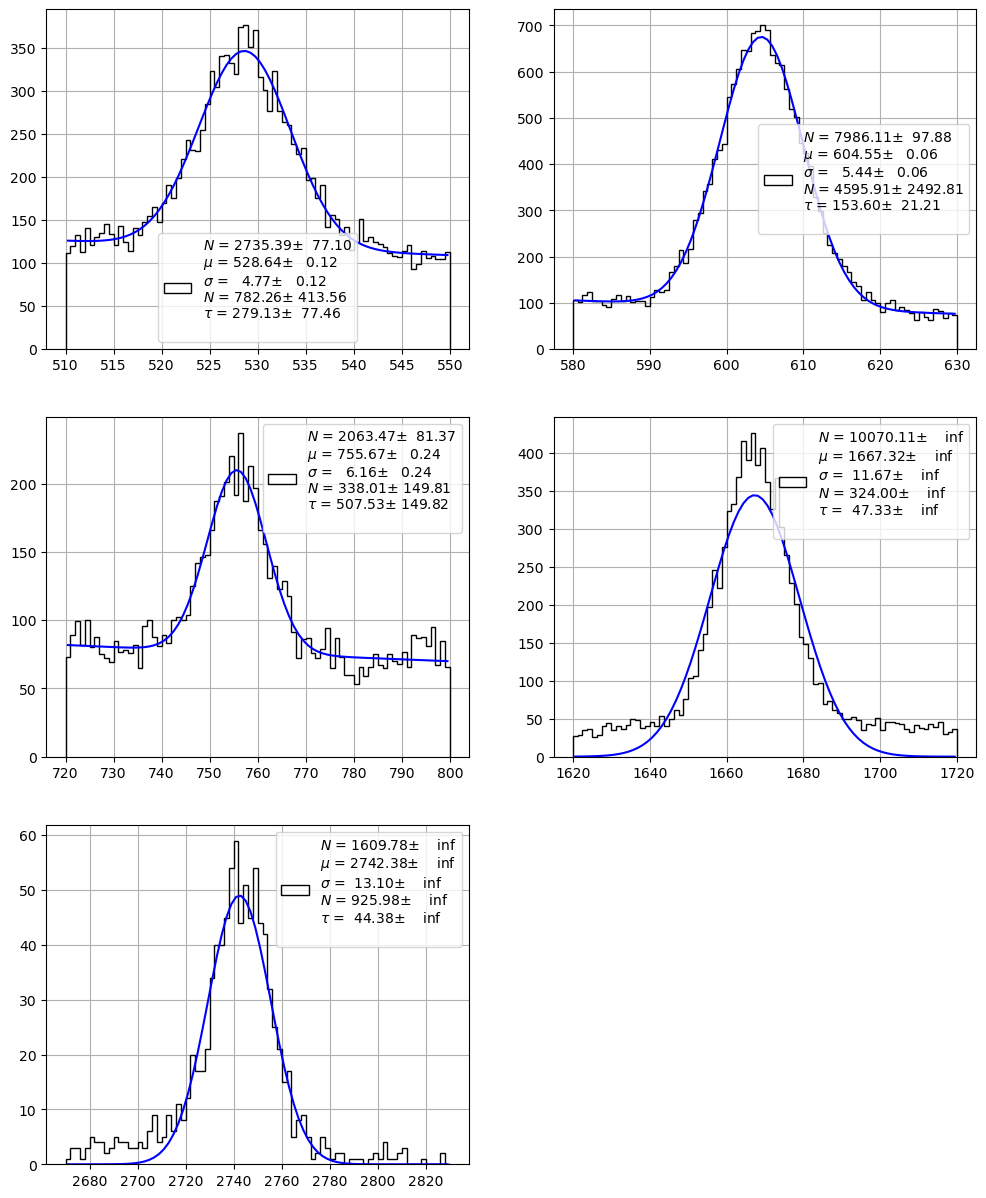

In [223]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
cv = pltext.canvas(6, 2)
p0 = np.array((1e2, 0.53, 0.05))
#for i, irange in enumerate(peak_ranges_d):
i = 5
for i, irange in enumerate(pranges):
    cv(i+1); pltext.hfit(1e3*energy, fun = 'gaus+exp', bins = 80, range = 1e3*np.array(irange));
#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [196]:
pranges  = [(0.51, 0.55), (0.58, 0.63), (0.72, 0.80), (1.62, 1.72), (2.67, 2.83)]
vals = [get_peak(1e3*energy, range = 1e3*np.array(irange), bins = 400) for irange in pranges]#vals = [get_peak(energy, range) for range in peak_ranges_d]

In [197]:
vals

[(529.1221765269046,
  0.04312056612790292,
  4.999026251331807,
  0.04663885827662838),
 (605.1350336390645,
  0.023814021632212645,
  5.4754554218904,
  0.023210208268350734),
 (756.5705992685588,
  0.08337091634140209,
  6.162107646604556,
  0.08365794396834988),
 (1668.8612462301135,
  0.04876067731261533,
  8.593481308799348,
  0.04452136548869566),
 (2745.03749804094,
  0.19411825846338812,
  12.365539322467907,
  0.17479739947992182)]

## Result: energy scale and resolution
Comparison of measured vs true peak positions. Computed quantities:
- Measured peak position vs true energy
- Peak sigma as a function of energy
- FWHM/E (%) - relative energy resolution
- FWHM/E extrapolated to Q_betabeta (2458 keV)

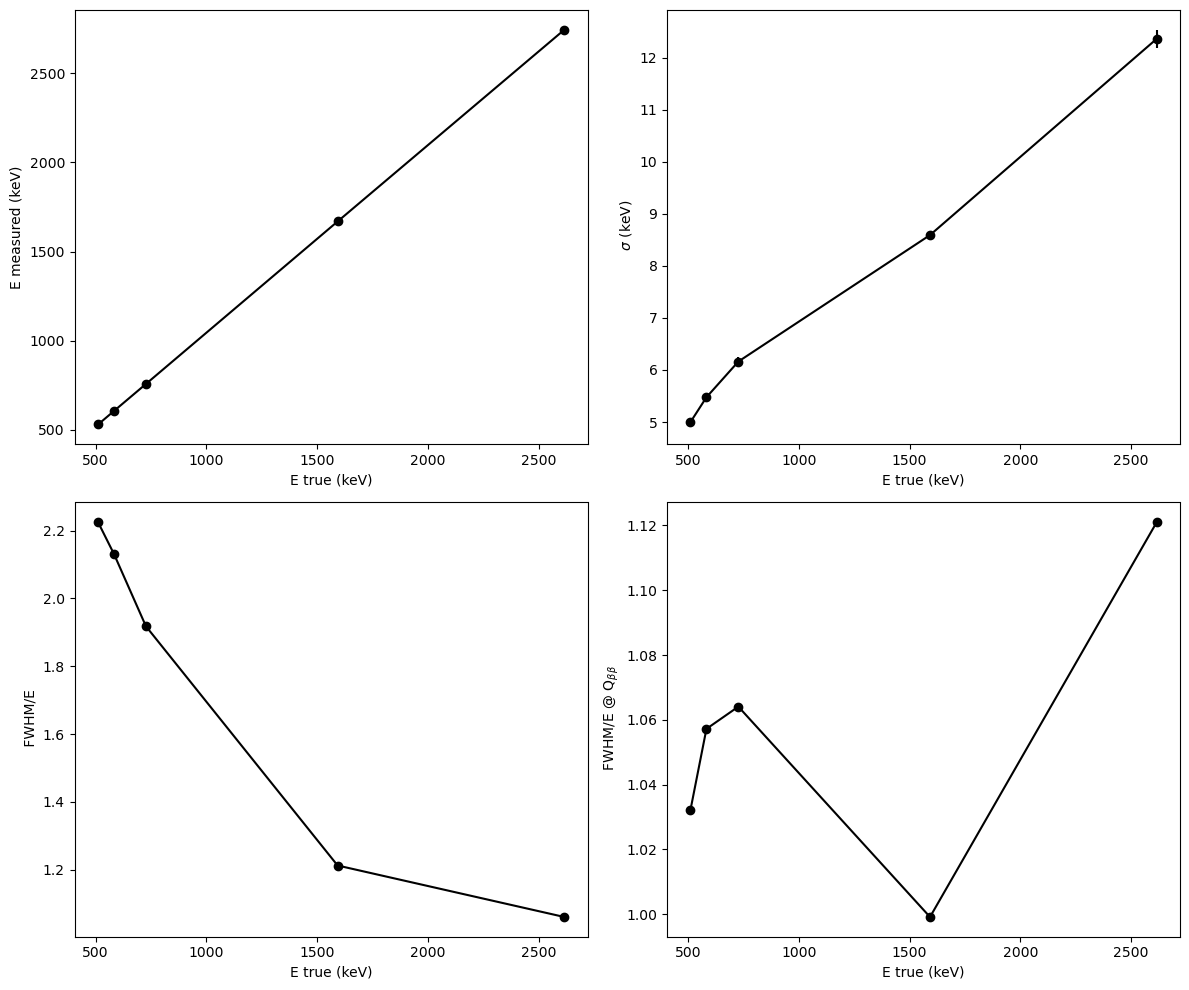

In [207]:
peak_true  = 1e3*np.array([0.511, 0.583, 0.727, 1.592, 2.615])
peak_meas  = np.array([v[0] for v in vals])
peak_emeas = np.array([v[1] for v in vals])
peak_sig   = np.array([v[2] for v in vals])
peak_esig  = np.array([v[3] for v in vals])
Qbb = 2458.
cv = pltext.canvas(3, 2)
cv(1); plt.errorbar(peak_true, peak_meas, yerr = peak_emeas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel("E measured (keV)")
cv(2); plt.errorbar(peak_true, peak_sig, yerr = peak_esig, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" $\sigma$ (keV)")
cv(3); plt.plot(peak_true, 235.48 * peak_sig/peak_meas, marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E")
cv(4); plt.plot(peak_true, 235.48 * peak_sig /peak_meas * np.sqrt(peak_meas/Qbb), marker= 'o');
plt.xlabel("E true (keV)"); plt.ylabel(r" FWHM/E @ Q$_{\beta\beta}$")
plt.tight_layout();


In [ ]:
pltext.hist(reco_summ.total_energy_d, 500, (0, 3));

,event,npeak,run_n,file_n,ldc_n,time,dX,dY,dZ,Xmin,...,X_bary,Y_bary,Z_bary,total_E,total_energy,num_hits,Ec_drop_in,nhits_drop_in,Ec_drop_out,nhits_drop_out
11,120,32,15589,0000,ldc1,1.751990e+09,400.30,277.40,163.531875,-19.125,...,268.259795,-140.575041,663.460993,339022.818697,1.852308,1261,0.041174,83,0.008404,21
43,442,32,15589,0000,ldc1,1.751990e+09,107.85,107.85,63.406375,88.725,...,139.036401,43.714905,912.947330,63996.899463,0.351425,229,0.012001,13,0.004922,16
65,687,21,15589,0000,ldc1,1.751990e+09,170.05,170.05,147.313125,134.375,...,211.142176,-219.095438,819.622523,331282.290316,1.794716,1286,0.040074,74,0.006229,10
23,883,18,15589,0001,ldc1,1.751990e+09,123.40,123.40,27.127250,-328.125,...,-267.817024,-61.531167,919.496907,69378.268448,0.386220,253,0.006537,12,0.014065,16
53,1135,36,15589,0001,ldc1,1.751990e+09,215.70,154.00,78.885000,-312.575,...,-168.523569,-37.438234,398.525620,143315.489953,0.755627,486,0.014002,31,0.008478,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3828076,18,15597,5370,ldc7,1.752674e+09,185.60,262.35,127.080500,-96.875,...,-15.589238,159.308605,693.238208,110677.212640,0.598111,456,0.020475,38,0.001844,12
13,3828230,22,15597,5370,ldc7,1.752674e+09,138.95,138.95,26.769250,288.875,...,355.499240,-6.786320,577.540461,64412.395411,0.366932,223,0.008872,22,0.006377,9
47,3828531,31,15597,5370,ldc7,1.752674e+09,170.05,339.10,47.254250,-81.325,...,1.523561,103.155084,935.400033,114267.442543,0.617315,479,0.018765,29,0.003201,4
54,3828566,19,15597,5370,ldc7,1.752674e+09,123.40,462.50,71.389000,104.275,...,163.573332,-75.092490,851.997868,64883.624815,0.359839,249,0.019170,22,0.004064,20
